In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl

g = 9.805
mpl.rc('font',family='Times New Roman')

In [2]:
def Gamma(D1):
    s = 0
    ss = 0
    for i in range(len(D1)):
        s = D1[i]*m[i] + s
        ss = D1[i]**2*m[i] + ss
    return s/ss, s**2/ss

In [3]:
m = [0, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0.363, 0, 0.363, 
     0.363, 0.363, 0.363, 0.363, 0.363, 0]

In [4]:
im = 9

In [5]:
model = 'M01_biron'

In [6]:
dispX = np.loadtxt(model+"_DispX.txt")
dispY = np.loadtxt(model+"_DispY.txt")

In [7]:
Dxm = np.zeros(10)
Dym = np.zeros(10)

for i in range(len(Dxm)):
    dx = dispX[:,i]
    dx = dx[dx != 0]
    Dxm[i] = np.median(dx)
    
    dy = dy = dispY[:,i]
    dy = dy[dy != 0]
    Dym[i] = np.median(dy)

In [8]:
data = np.load("M01_peak_displacements.npy", allow_pickle=True).item()

dispXs = data["dispXs"]
dispYs = data["dispYs"]

In [9]:
DxmS = np.zeros(10)
DymS = np.zeros(10)

for i in range(10):
    DxmS[i] = np.median(dispXs[:,i])
    DymS[i] = np.median(dispYs[:,i])


Text(0, 0.5, 'Peak Suspended Piping Displacement')

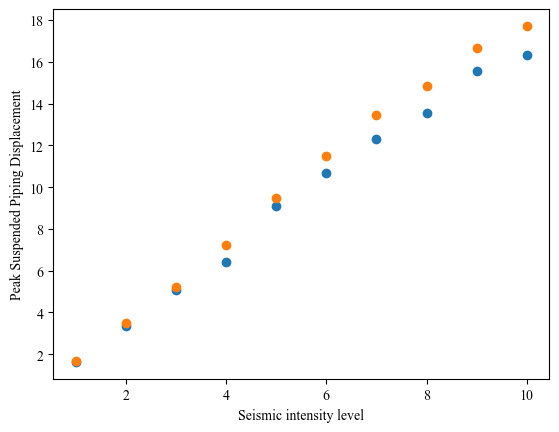

In [95]:
im = [1,2,3,4,5,6,7,8,9,10]
plt.scatter(im,Dxm)
plt.scatter(im,DxmS*0.92*1.14)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'Peak Suspended Piping Displacement')

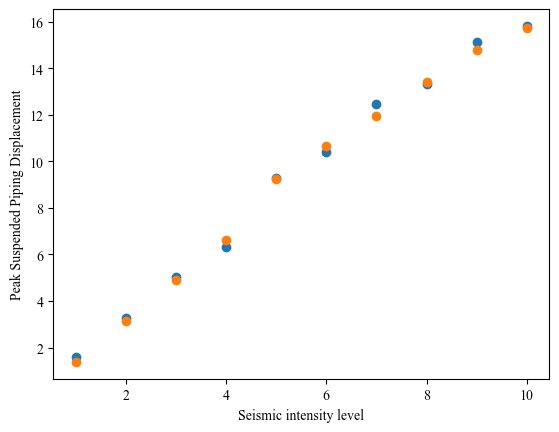

In [97]:

#plt.scatter(im,Dxm)
plt.scatter(im,Dym)
plt.scatter(im,DymS*0.891*1.16)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'MRE')

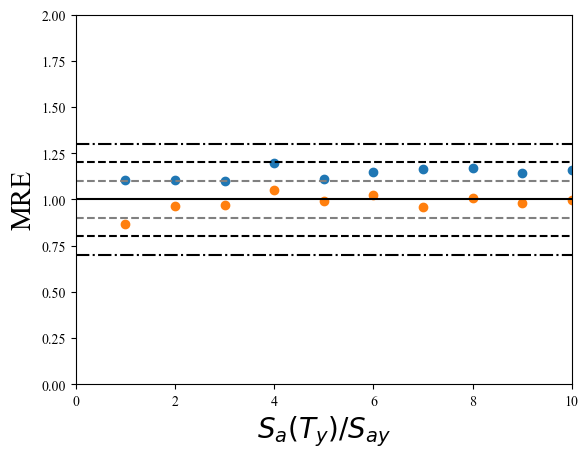

In [98]:
plt.scatter(im,DxmS*0.92*1.216/Dxm)
plt.scatter(im,DymS*0.891*1.16/Dym)

plt.plot((0,10),(1.1,1.1),color='grey',ls='--')
plt.plot((0,10),(0.9,0.9),color='grey',ls='--')

plt.plot((0,10),(1.2,1.2),color='k',ls='--')
plt.plot((0,10),(0.8,0.8),color='k',ls='--')

plt.plot((0,10),(1.3,1.3),color='k',ls='-.')
plt.plot((0,10),(0.7,0.7),color='k',ls='-.')

plt.plot((0,10),(1,1),color='k')
plt.ylim(0,2)
plt.xlim(0,10)
plt.xlabel(r'$S_{a}(T_y)/S_{ay}$',fontsize=20)
plt.ylabel(r'MRE',fontsize=20)

In [99]:
DispShapeX = np.load(model+"DispShapeX.npy")
DispShapeY = np.load(model+"DispShapeY.npy")

In [100]:
def DispShapeStat(DispShapeX,DispShapeY):
    tol = 0
    mask_rowsX = np.any(DispShapeX > tol, axis=(1))
    mask_rowsY = np.any(DispShapeY > tol, axis=(1))
    
    DispShapeX_no_zero = DispShapeX[mask_rowsX, :]
    DispShapeY_no_zero = DispShapeY[mask_rowsY, :]
    
    DSXm = DispShapeX_no_zero.mean(axis=0)
    DSYm = DispShapeY_no_zero.mean(axis=0)
    
    DSXs = DispShapeX_no_zero.std(axis=0)
    DSYs = DispShapeY_no_zero.std(axis=0)

    return DSXm,DSYm,DSXs,DSYs

In [101]:
DSXm = np.zeros((21,10))
DSYm = np.zeros((21,10))

DSXs = np.zeros((21,10))
DSYs = np.zeros((21,10))

for i in range(10):
    DSXm[:,i],DSYm[:,i],DSXs[:,i],DSYs[:,i] = DispShapeStat(DispShapeX[:,:,i],DispShapeY[:,:,i])

In [16]:

POy = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M01y.txt')
POx = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M01x.txt')

In [17]:
Vbx_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM01x_SDOF/VbaseC.out')
Dx_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM01x_SDOF/DispC.out')

In [18]:
Vby_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM01y_SDOF/VbaseC.out')
Dy_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM01y_SDOF/DispC.out')

In [19]:
Fx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM01_biron/ReactionsX.out')

Vbx_3D = np.zeros(len(Fx_3D[:,0]))
for i in range(len(Vbx_3D)):
    Vbx_3D[i] = -1*np.sum(Fx_3D[i,1:])

Dx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM01_biron/PipeNodeDispX.out')

Dx3D_eq = np.zeros(len(Dx_3D[:,0]))
for i in range(len(Dx3D_eq)):
    Dx3D_eq[i] = np.sum(Dx_3D[i,1:]**2)/np.sum(Dx_3D[i,1:])


In [20]:
Fy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM01_biron/ReactionsY.out')

Vby_3D = np.zeros(len(Fy_3D[:,0]))
for i in range(len(Vby_3D)):
    Vby_3D[i] = -1*np.sum(Fy_3D[i,1:])

Dy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM01_biron/PipeNodeDispY.out')

Dy3D_eq = np.zeros(len(Dy_3D[:,0]))
for i in range(len(Dy3D_eq)):
    Dy3D_eq[i] = np.sum(Dy_3D[i,1:]**2)/np.sum(Dy_3D[i,1:])


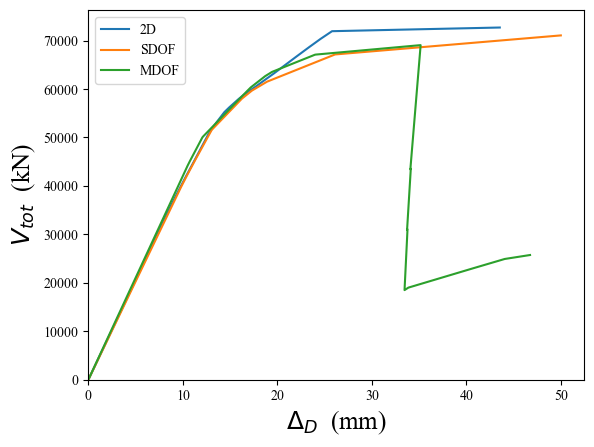

In [65]:
plt.plot(POx[:,5],POx[:,3],label='2D')
plt.plot(Dx_SDOF,Vbx_SDOF,label='SDOF')
plt.plot(Dx3D_eq,Vbx_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

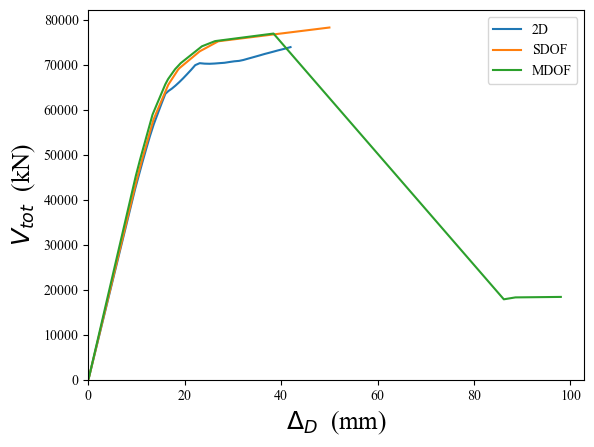

In [67]:
plt.plot(POy[:,5],POy[:,3],label='2D')
plt.plot(Dy_SDOF,Vby_SDOF,label='SDOF')
plt.plot(Dy3D_eq,Vby_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

In [68]:
Dstaticx = POx[:,6:13]
Dstaticx = np.flip(Dstaticx)

In [69]:
im =5

In [70]:
Dstaticy = POy[:,6:19]


In [71]:
x0 = np.zeros(21)
y0 = np.zeros(21)

x0[1] = 1

for i in range(2,len(x0)):
    if(i<13):
        x0[i] = 3*(i-1)+x0[1]
    else:
        x0[i] = 36

y0[14] = 1        
for i in range(15,20):
    y0[i] = y0[14]+3*(i-14)

y0[20] = 18

In [72]:
dsdx = np.ones(len(x0))
print(x0[14:])
dsdx[14:] = np.multiply(dsdx[14:],Dstaticx[10,:])

[36. 36. 36. 36. 36. 36. 36.]


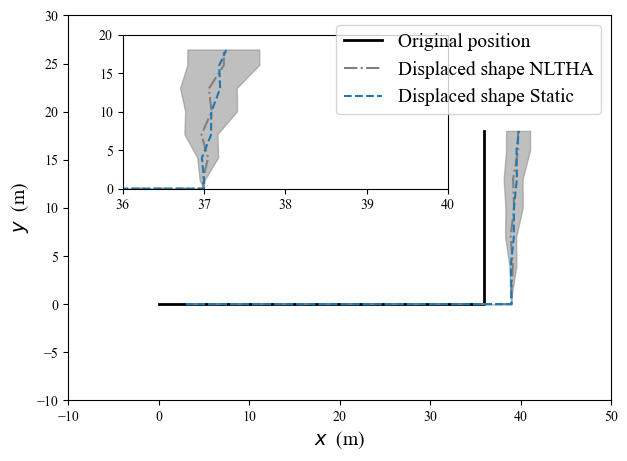

In [73]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0,y0, color='k',lw=2,label='Original position')
ax.plot(x0+3*DSXm[:,im],y0, color='grey',ls='-.',label='Displaced shape NLTHA')
ax.fill_betweenx(y0,x0+3*(DSXm[:,im]+2*DSXs[:,im]),x0+3*(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.5)
ax.plot(x0+3*dsdx,y0, color='C0',ls='--',label='Displaced shape Static')
axins1 = ax.inset_axes([0.1, 0.55, 0.6, 0.4],xlim=(36,40), ylim=(0, 20))
axins1.plot(x0+DSXm[:,im],y0, color='grey',ls='-.',label='Displaced shape NLTHA')
axins1.fill_betweenx(y0,x0+(DSXm[:,im]+2*DSXs[:,im]),x0+(DSXm[:,im]-2*DSXs[:,im]),color='grey',alpha=0.5)
axins1.plot(x0+dsdx,y0, color='C0',ls='--',label='Displaced shape Static')
#plt.plot(x0+3*np.ones(len(x0)),y0, color='C0',ls='--',label='Displaced shape Static')


ax.set_xlim(-10,50)
ax.set_ylim(-10,30)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=14)

In [74]:
Gx_NLTH, mx_NLTH = Gamma(DSXm[:,5])
Gx_NLTH

0.9754099511775138

In [75]:
mx_NLTH/np.sum(m)

0.996517024181437

In [76]:
mx_NLTH

6.511242236001508

In [77]:
np.sum(m)

6.533999999999999

In [78]:
Gx_static = POx[20,1]
Gx_static

0.924

In [79]:
mx_static = POx[20,2]
mx_static

6.574

In [80]:
POx[20,4]

0.985

In [81]:
abs(Gx_static-Gx_NLTH)/Gx_NLTH

0.05270599414682181

In [82]:
abs(mx_static-mx_NLTH)/mx_NLTH

0.009638370333005838

In [83]:
Dstaticx[5,:]

array([1.   , 0.976, 1.069, 1.068, 1.157, 1.144, 1.216])

In [84]:
dsdy = np.ones(len(y0))
print(y0[:14])
ix = 9
dsdy[:14] = np.multiply(dsdy[:14],np.append(Dstaticy[ix,0],Dstaticy[ix,:]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


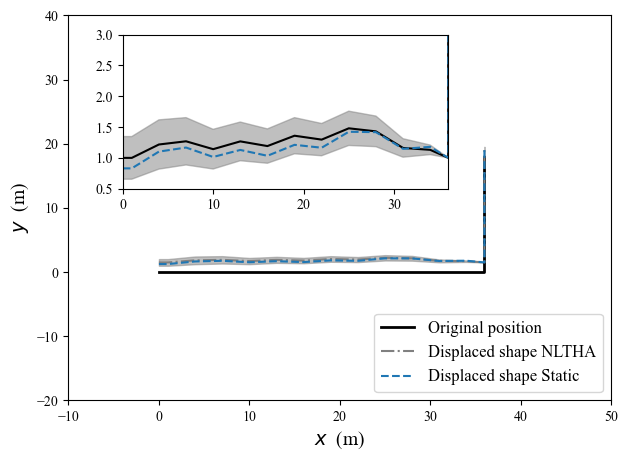

In [85]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0,y0, color='k',lw=2,label='Original position')
ax.plot(x0,y0+1.5*DSYm[:,im], color='grey',ls='-.',label='Displaced shape NLTHA')
ax.plot(x0,y0+1.5*dsdy, color='C0',ls='--',label='Displaced shape Static')
ax.fill_between(x0,y0+1.5*(DSYm[:,im]+2*DSYs[:,im]),y0+1.5*(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
axins1 = ax.inset_axes([0.1, 0.55, 0.6, 0.4],xlim=(0,36), ylim=(0.5, 3))
axins1.plot(x0,y0+DSYm[:,im],color='k')
axins1.fill_between(x0,y0+(DSYm[:,im]+2*DSYs[:,im]),y0+(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
axins1.plot(x0,y0+dsdy, color='C0',ls='--',label='Displaced shape Static')
#ax.indicate_inset_zoom(axins1, edgecolor="black")

ax.set_xlim(-10,50)
ax.set_ylim(-20,40)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)
#plt.xlim(-5,40)
#plt.ylim(0,4)
plt.legend(fontsize=12,loc=4)

In [86]:
Gy_NLTH, my_NLTH = Gamma(DSYm[:,5])
Gy_NLTH

0.8445123639262971

In [87]:
modal_my_NLTH = my_NLTH/np.sum(m)

In [88]:
my_NLTH

6.4177885427083075

In [89]:
Gy_static = POy[10,1]
Gy_static

0.891

In [90]:
my_static = POy[10,2]
my_static

6.567

In [91]:
modal_my_static = POy[10,4]

In [92]:
abs(Gy_static-Gy_NLTH)/Gy_NLTH

0.05504672052114559

In [56]:
abs(modal_my_NLTH-modal_my_static)/my_NLTH

0.00027823495248663165

In [57]:
Dstaticy[5,:]

array([0.829, 1.101, 1.167, 1.014, 1.128, 1.033, 1.211, 1.164, 1.423,
       1.417, 1.146, 1.178, 1.   ])